In [2]:
# ================================================================
#  NASA C-MAPSS — AŞAMA 1 (TÜM SUBSETLER)
#  FD001 → FD002 → FD003 → FD004
#
#  FD001 checkpoint'leri zaten hazır — atlanır.
#  FD002/003/004 sırayla eğitilir.
#
#  Sonunda 4 subset karşılaştırma tablosu + grafik üretilir.
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time, warnings, os, zipfile, shutil, copy, json
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_RUL = 125
SEQ_LEN = 30

print(f"Cihaz: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU  : {torch.cuda.get_device_name(0)}")

from google.colab import drive
drive.mount('/content/drive')

# ── Tüm checkpointler tek ana dizin altında ──────
BASE_CKPT = '/content/drive/MyDrive/cmapss_checkpoints/asama1'
BASE_OUT  = '/content/drive/MyDrive/cmapss_asama1'
os.makedirs(BASE_CKPT, exist_ok=True)
os.makedirs(BASE_OUT,  exist_ok=True)

Cihaz: cuda
GPU  : Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# ╔══════════════════════════════════════════════════╗
# ║  VERİ                                            ║
# ╚══════════════════════════════════════════════════╝

DATA_DIR = '/content/CMAPSSData'
if not os.path.exists(DATA_DIR):
    OUTER_ZIP = '/content/drive/MyDrive/TurbofanEğitimi/6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip'
    with zipfile.ZipFile(OUTER_ZIP, 'r') as z:
        z.extractall('/content/outer_zip')
    inner_zip = None
    for root, dirs, files in os.walk('/content/outer_zip'):
        for f in files:
            if f.endswith('.zip'):
                inner_zip = os.path.join(root, f)
    with zipfile.ZipFile(inner_zip, 'r') as z:
        z.extractall(DATA_DIR)

COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]

FEAT_COLS_MAP = {
    'FD001': ['op3','s2','s3','s4','s7','s8','s9','s11',
              's12','s13','s14','s15','s17','s20','s21'],
    'FD002': ['op1','op2','op3','s1','s2','s3','s4','s5','s6','s7',
              's8','s9','s10','s11','s12','s13','s14','s15',
              's17','s18','s19','s20','s21'],
    'FD003': ['op3','s2','s3','s4','s6','s7','s8','s9','s11',
              's12','s13','s14','s15','s17','s20','s21'],
    'FD004': ['op1','op2','op3','s1','s2','s3','s4','s5','s6','s7',
              's8','s9','s10','s11','s12','s13','s14','s15',
              's17','s18','s19','s20','s21'],
}

# FD001 referans değerleri (Aşama 1 sonucundan)
FD001_REF = {
    'Bi-LSTM 50ep':     {'RMSE': 13.430, 'R2': 0.7959, 'Score': 30901.6},
    'Bi-LSTM v2 ES':    {'RMSE': 13.231, 'R2': 0.8019, 'Score': 35646.4},
    'Transformer ES':   {'RMSE': 13.555, 'R2': 0.7921, 'Score': 43847.9},
    'Basit Ensemble':   {'RMSE': 13.104, 'R2': 0.8057, 'Score': 36731.5},
    'GRU Stacking':     {'RMSE': 13.247, 'R2': 0.8014, 'Score': 40448.6},
}

def load_and_prepare(subset):
    feat_cols = FEAT_COLS_MAP[subset]
    train = pd.read_csv(f'{DATA_DIR}/train_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    test  = pd.read_csv(f'{DATA_DIR}/test_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    rul   = pd.read_csv(f'{DATA_DIR}/RUL_{subset}.txt',
                        sep=r'\s+', header=None, names=['rul'], engine='python')

    mc = train.groupby('unit')['cycle'].max()
    train['rul'] = (train['unit'].map(mc) - train['cycle']).clip(0, MAX_RUL)

    last = test.groupby('unit').last().reset_index()
    last['final_rul'] = rul['rul'].values
    lc = test.groupby('unit')['cycle'].max().reset_index()
    lc.columns = ['unit', 'last_cycle']
    test = test.merge(last[['unit','final_rul']], on='unit', how='left')
    test = test.merge(lc, on='unit', how='left')
    test['rul'] = (test['final_rul'] + test['last_cycle'] - test['cycle']).clip(0, MAX_RUL)
    test.drop(columns=['final_rul','last_cycle'], inplace=True)

    scaler = MinMaxScaler()
    train[feat_cols] = scaler.fit_transform(train[feat_cols])
    test[feat_cols]  = scaler.transform(test[feat_cols])

    def make_seq(df):
        X, y = [], []
        for _, g in df.groupby('unit'):
            g = g.sort_values('cycle')
            v = g[feat_cols].values; r = g['rul'].values
            for i in range(len(v) - SEQ_LEN + 1):
                X.append(v[i:i+SEQ_LEN]); y.append(r[i+SEQ_LEN-1])
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

    X_tr, y_tr = make_seq(train)
    X_te, y_te = make_seq(test)
    print(f"[{subset}] Train: {X_tr.shape} | Test: {X_te.shape} | "
          f"Özellik: {len(feat_cols)}")
    return {'subset': subset, 'n_feat': len(feat_cols),
            'X_tr': X_tr, 'y_tr': y_tr, 'X_te': X_te, 'y_te': y_te}

def nasa_score(y_true, y_pred):
    d = np.array(y_pred) - np.array(y_true)
    return float(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1).sum())

def get_metrics(y_true, y_pred):
    return {
        'RMSE':  float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE':   float(mean_absolute_error(y_true, y_pred)),
        'R2':    float(r2_score(y_true, y_pred)),
        'Score': nasa_score(y_true, y_pred),
    }

In [4]:
# ╔══════════════════════════════════════════════════╗
# ║  CHECKPOINT                                      ║
# ╚══════════════════════════════════════════════════╝

def ckpt_dir(subset):
    d = os.path.join(BASE_CKPT, subset)
    os.makedirs(d, exist_ok=True)
    return d

def save_ckpt(model, metrics, name, subset):
    d    = ckpt_dir(subset)
    path = os.path.join(d, f'{name}_{subset}.pt')
    torch.save(model.state_dict(), path)
    meta = {k: v for k, v in metrics.items() if k != 'history'}
    with open(path.replace('.pt','.json'), 'w') as f:
        json.dump(meta, f, indent=2)
    print(f"  ✓ Checkpoint kaydedildi → {path}")

def load_ckpt(model, name, subset):
    d    = ckpt_dir(subset)
    path = os.path.join(d, f'{name}_{subset}.pt')
    if not os.path.exists(path):
        return model, None
    model.load_state_dict(torch.load(path, map_location=DEVICE))
    model = model.to(DEVICE)
    meta_path = path.replace('.pt', '.json')
    metrics = json.load(open(meta_path)) if os.path.exists(meta_path) else None
    if metrics:
        print(f"  ✓ {name}_{subset} yüklendi: "
              f"RMSE={metrics.get('RMSE',0):.3f}  "
              f"R²={metrics.get('R2',0):.4f}")
    return model, metrics

def ckpt_exists(name, subset):
    return os.path.exists(
        os.path.join(ckpt_dir(subset), f'{name}_{subset}.pt'))

def oof_path(name, subset):
    return os.path.join(ckpt_dir(subset), f'oof_{name}_{subset}.npy')

In [5]:
# ╔══════════════════════════════════════════════════╗
# ║  EARLY STOPPING                                  ║
# ╚══════════════════════════════════════════════════╝

class EarlyStopping:
    def __init__(self, patience=15, min_delta=0.05):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_rmse  = float('inf')
        self.best_state = None
        self.best_ep    = 0

    def step(self, rmse, model, epoch):
        if rmse < self.best_rmse - self.min_delta:
            self.best_rmse  = rmse
            self.best_state = copy.deepcopy(model.state_dict())
            self.best_ep    = epoch
            self.counter    = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)
        return model

In [6]:
import torch
import torch.nn as nn

# ╔══════════════════════════════════════════════════╗
# ║  MODELLEr                                        ║
# ╚══════════════════════════════════════════════════╝

class BiLSTM_v2(nn.Module):
    def __init__(self, n_feat, hidden=256, layers=3, dropout=0.30):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, layers,
                            batch_first=True, dropout=dropout, bidirectional=True)
        self.norm = nn.LayerNorm(hidden * 2)
        self.fc = nn.Sequential(
            nn.Linear(hidden*2, 128), nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.norm(out[:, -1])).flatten()

class TransformerRUL(nn.Module):
    def __init__(self, n_feat, d_model=128, nhead=4, layers=3, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_feat, d_model)
        self.pos_enc    = nn.Parameter(torch.randn(1, SEQ_LEN, d_model) * 0.01)
        enc = nn.TransformerEncoderLayer(d_model, nhead, 256, dropout,
                                          batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 64), nn.ReLU(), nn.Dropout(0.1), nn.Linear(64, 1)
        )
    def forward(self, x):
        x = self.input_proj(x) + self.pos_enc
        return self.fc(self.transformer(x)[:, -1]).flatten()

class GRUMetaModel(nn.Module):
    def __init__(self, n_feat, gru_hidden=64):
        super().__init__()
        self.gru       = nn.GRU(n_feat, gru_hidden, 1, batch_first=True)
        self.pred_proj = nn.Sequential(nn.Linear(2, 16), nn.ReLU())
        self.fusion    = nn.Sequential(
            nn.Linear(gru_hidden+16, 64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1)
        )
    def forward(self, x, p1, p2):
        _, h = self.gru(x)
        ctx  = h.squeeze(0)
        pf   = self.pred_proj(torch.stack([p1,p2], dim=1))
        return self.fusion(torch.cat([ctx, pf], dim=1)).flatten()

In [7]:
# ╔══════════════════════════════════════════════════╗
# ║  EĞİTİM FONKSİYONLARI                          ║
# ╚══════════════════════════════════════════════════╝

def train_base(model, data, max_ep=200, lr=1e-3, batch=256,
               patience=15, name='', ck_name=None):
    subset = data['subset']

    # Checkpoint kontrolü — FD001 zaten hazır
    if ck_name and ckpt_exists(ck_name, subset):
        print(f"\n  [{subset}][{name}] Checkpoint mevcut → yükleniyor")
        model, saved = load_ckpt(model, ck_name, subset)
        model.eval()
        all_preds = []
        eval_loader = DataLoader(TensorDataset(torch.tensor(data['X_te']).to(DEVICE)), batch_size=batch)
        with torch.no_grad():
            for xb_eval in eval_loader:
                preds_batch = model(xb_eval[0]).cpu().numpy().reshape(-1)
                all_preds.append(preds_batch)
        preds = np.concatenate(all_preds)
        m = get_metrics(data['y_te'], preds)
        m['best_ep'] = saved.get('best_ep', '?') if saved else '?'
        m['history'] = {'epoch':[], 'rmse':[], 'r2':[]}
        return m, preds, model

    model = model.to(DEVICE)
    X_tr  = torch.tensor(data['X_tr']).to(DEVICE)
    y_tr  = torch.tensor(data['y_tr']).to(DEVICE)
    X_te  = torch.tensor(data['X_te']).to(DEVICE)

    loader = DataLoader(TensorDataset(X_tr, y_tr), batch, shuffle=True)
    opt  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(
               opt, 'min', factor=0.5, patience=10, min_lr=1e-6)
    crit = nn.HuberLoss(delta=10.0)
    es   = EarlyStopping(patience=patience, min_delta=0.05)
    hist = {'epoch':[], 'rmse':[], 'r2':[]}
    t0   = time.time()

    print(f"\n{'─'*60}")
    print(f"  {name} | {subset} | max {max_ep} ep | patience={patience} | "
          f"{sum(p.numel() for p in model.parameters()):,} param")
    print(f"{'─'*60}")

    for ep in range(1, max_ep+1):
        model.train()
        losses = []
        for xb, yb in loader:
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(loss.item())

        model.eval()
        all_preds = []
        eval_loader = DataLoader(TensorDataset(X_te), batch_size=batch)
        with torch.no_grad():
            for xb_eval in eval_loader:
                preds_batch = model(xb_eval[0]).cpu().numpy().reshape(-1)
                all_preds.append(preds_batch)
        preds = np.concatenate(all_preds)
        rmse = float(np.sqrt(mean_squared_error(data['y_te'], preds)))
        r2   = float(r2_score(data['y_te'], preds))
        sch.step(rmse)
        hist['epoch'].append(ep); hist['rmse'].append(rmse); hist['r2'].append(r2)

        if ep % 10 == 0 or ep == 1:
            print(f"  Ep {ep:4d}/{max_ep}  Loss={np.mean(losses):8.3f}  "
                  f"RMSE={rmse:7.3f}  R²={r2:.4f}  "
                  f"lr={opt.param_groups[0]['lr']:.2e}  ES={es.counter}/{patience}")

        if es.step(rmse, model, ep):
            print(f"\n  ⚡ Early Stop: ep {ep} | Best → ep {es.best_ep}, RMSE={es.best_rmse:.3f}")
            break

    model = es.restore(model)
    model.eval()
    all_best_preds = []
    eval_loader_final = DataLoader(TensorDataset(X_te), batch_size=batch)
    with torch.no_grad():
        for xb_eval_final in eval_loader_final:
            preds_batch_final = model(xb_eval_final[0]).cpu().numpy().reshape(-1)
            all_best_preds.append(preds_batch_final)
    best_preds = np.concatenate(all_best_preds)

    m = get_metrics(data['y_te'], best_preds)
    m['Time'] = time.time()-t0; m['history'] = hist; m['best_ep'] = es.best_ep
    print(f"\n  ✓ {name} [{subset}]: RMSE={m['RMSE']:.3f}  R²={m['R2']:.4f}  "
          f"({m['Time']/60:.1f} dk | best ep={es.best_ep})")
    if ck_name:
        save_ckpt(model, m, ck_name, subset)
    return m, best_preds, model


def get_oof(ModelClass, kwargs, X, y, subset,
            n_splits=5, max_ep=150, lr=1e-3, batch=256,
            patience=15, name='', ck_name=None):

    if ck_name:
        op = oof_path(ck_name, subset)
        if os.path.exists(op):
            print(f"\n  [{name}] OOF checkpoint → yükleniyor")
            oof = np.load(op)
            print(f"  OOF RMSE: {float(np.sqrt(mean_squared_error(y, oof))):.3f}")
            return oof

    print(f"\n  [{name}] OOF — {n_splits} fold (max {max_ep} ep, patience={patience})")
    oof = np.zeros(len(y), dtype=np.float32)
    kf  = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    for fold, (ti, vi) in enumerate(kf.split(X)):
        Xtr = torch.tensor(X[ti]).to(DEVICE); ytr = torch.tensor(y[ti]).to(DEVICE)
        Xva = torch.tensor(X[vi]).to(DEVICE)
        mdl  = ModelClass(**kwargs).to(DEVICE)
        opt  = torch.optim.AdamW(mdl.parameters(), lr=lr, weight_decay=1e-4)
        sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,'min',0.5,8,min_lr=1e-6)
        crit = nn.HuberLoss(delta=10.0)
        es   = EarlyStopping(patience=patience, min_delta=0.05)
        dl   = DataLoader(TensorDataset(Xtr,ytr), batch, shuffle=True)

        for ep in range(max_ep):
            mdl.train()
            for xb,yb in dl:
                opt.zero_grad(); loss=crit(mdl(xb),yb); loss.backward()
                nn.utils.clip_grad_norm_(mdl.parameters(),1.0); opt.step()
            mdl.eval()
            all_vp = []
            eval_loader_oof = DataLoader(TensorDataset(Xva), batch_size=batch)
            with torch.no_grad():
                for xb_eval_oof in eval_loader_oof:
                    vp_batch = mdl(xb_eval_oof[0]).cpu().numpy().reshape(-1)
                    all_vp.append(vp_batch)
            vp = np.concatenate(all_vp)
            vr = float(np.sqrt(mean_squared_error(y[vi],vp)))
            sch.step(vr)
            if es.step(vr, mdl, ep+1): break

        mdl = es.restore(mdl); mdl.eval()
        all_oof_preds = []
        eval_loader_oof_final = DataLoader(TensorDataset(Xva), batch_size=batch)
        with torch.no_grad():
            for xb_eval_oof_final in eval_loader_oof_final:
                oof_preds_batch = mdl(xb_eval_oof_final[0]).cpu().numpy().reshape(-1)
                all_oof_preds.append(oof_preds_batch)
        oof[vi] = np.concatenate(all_oof_preds)
        fr = float(np.sqrt(mean_squared_error(y[vi], oof[vi])))
        print(f"  Fold {fold+1}/{n_splits}  RMSE={fr:.3f}  (dur: ep {es.best_ep})")
        del mdl; torch.cuda.empty_cache()

    oof_rmse = float(np.sqrt(mean_squared_error(y, oof)))
    print(f"  [{name}] OOF toplam RMSE: {oof_rmse:.3f}")
    if ck_name:
        np.save(oof_path(ck_name, subset), oof)
        print(f"  ✓ OOF kaydedildi")
    return oof


def train_meta(meta, data, oof_bl, oof_tf, bl_preds, tf_preds,
               max_ep=100, lr=5e-4, batch=256, patience=20, subset=None):
    ck = 'meta'
    if ckpt_exists(ck, subset):
        print(f"\n  [Meta][{subset}] Checkpoint → yükleniyor")
        meta, saved = load_ckpt(meta, ck, subset)
        meta.eval()
        Xte = torch.tensor(data['X_te']).to(DEVICE)
        bt  = torch.tensor(bl_preds).to(DEVICE)
        tt  = torch.tensor(tf_preds).to(DEVICE)
        all_preds = []
        eval_loader_meta = DataLoader(TensorDataset(Xte, bt, tt), batch_size=batch)
        with torch.no_grad():
            for xb_eval, b1_eval, b2_eval in eval_loader_meta:
                preds_batch = meta(xb_eval, b1_eval, b2_eval).cpu().numpy().reshape(-1)
                all_preds.append(preds_batch)
        preds = np.concatenate(all_preds)
        m = get_metrics(data['y_te'], preds)
        m['best_ep'] = saved.get('best_ep','?') if saved else '?'
        m['history'] = {'epoch':[],'rmse':[],'r2':[]}
        print(f"  Yüklenen Meta: RMSE={m['RMSE']:.3f}")
        return m, preds

    meta = meta.to(DEVICE)
    Xtr  = torch.tensor(data['X_tr']).to(DEVICE)
    obl  = torch.tensor(oof_bl).to(DEVICE)
    otf  = torch.tensor(oof_tf).to(DEVICE)
    ytr  = torch.tensor(data['y_tr']).to(DEVICE)
    Xte  = torch.tensor(data['X_te']).to(DEVICE)
    bt   = torch.tensor(bl_preds).to(DEVICE)
    tt   = torch.tensor(tf_preds).to(DEVICE)

    loader = DataLoader(TensorDataset(Xtr,obl,otf,ytr), batch, shuffle=True)
    opt  = torch.optim.AdamW(meta.parameters(), lr=lr, weight_decay=1e-4)
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,'min',0.5,8,min_lr=1e-6)
    crit = nn.HuberLoss(delta=10.0)
    es   = EarlyStopping(patience=patience, min_delta=0.02)
    hist = {'epoch':[],'rmse':[],'r2':[]}
    t0   = time.time()

    print(f"\n{'─'*60}")
    print(f"  GRU Meta | {subset} | max {max_ep} ep | patience={patience}")
    print(f"{'─'*60}")

    for ep in range(1, max_ep+1):
        meta.train()
        losses = []
        for xb,b1,b2,yb in loader:
            opt.zero_grad(); loss=crit(meta(xb,b1,b2),yb)
            loss.backward(); nn.utils.clip_grad_norm_(meta.parameters(),1.0)
            opt.step(); losses.append(loss.item())

        meta.eval()
        all_preds = []
        eval_loader_meta = DataLoader(TensorDataset(Xte, bt, tt), batch_size=batch)
        with torch.no_grad():
            for xb_eval, b1_eval, b2_eval in eval_loader_meta:
                preds_batch = meta(xb_eval, b1_eval, b2_eval).cpu().numpy().reshape(-1)
                all_preds.append(preds_batch)
        preds = np.concatenate(all_preds)
        rmse = float(np.sqrt(mean_squared_error(data['y_te'],preds)))
        r2   = float(r2_score(data['y_te'],preds))
        sch.step(rmse)
        hist['epoch'].append(ep); hist['rmse'].append(rmse); hist['r2'].append(r2)

        if ep % 5 == 0 or ep == 1:
            print(f"  Ep {ep:3d}/{max_ep}  Loss={np.mean(losses):7.3f}  "
                  f"RMSE={rmse:7.3f}  R²={r2:.4f}  ES={es.counter}/{patience}")

        if es.step(rmse, meta, ep):
            print(f"\n  ⚡ Early Stop: ep {ep} | Best → ep {es.best_ep}, RMSE={es.best_rmse:.3f}")
            break

    meta = es.restore(meta); meta.eval()
    all_best_preds = []
    eval_loader_meta_final = DataLoader(TensorDataset(Xte, bt, tt), batch_size=batch)
    with torch.no_grad():
        for xb_eval_final, b1_eval_final, b2_eval_final in eval_loader_meta_final:
            preds_batch_final = meta(xb_eval_final, b1_eval_final, b2_eval_final).cpu().numpy().reshape(-1)
            all_best_preds.append(preds_batch_final)
    best_preds = np.concatenate(all_best_preds)

    m = get_metrics(data['y_te'], best_preds)
    m['Time']=time.time()-t0; m['history']=hist; m['best_ep']=es.best_ep
    print(f"\n  ✓ Meta [{subset}]: RMSE={m['RMSE']:.3f}  R²={m['R2']:.4f}  "
          f"({m['Time']/60:.1f} dk | best ep={es.best_ep})")
    save_ckpt(meta, m, ck, subset)
    return m, best_preds

In [8]:
# ╔══════════════════════════════════════════════════╗
# ║  TEK SUBSET PİPELİNE                            ║
# ╚══════════════════════════════════════════════════╝

def run_subset(subset):
    """
    Tek bir subset için tam pipeline:
    1. Veri yükle
    2. Bi-LSTM + Transformer eğit (checkpoint varsa atla)
    3. OOF tahminleri (checkpoint varsa atla)
    4. GRU Meta-Model eğit
    5. Basit Ensemble α tarama
    6. Sonuçları döndür
    """
    print(f"\n{'#'*62}")
    print(f"  {subset} EĞİTİMİ BAŞLIYOR")
    print(f"{'#'*62}")

    data = load_and_prepare(subset)
    N    = data['n_feat']

    # ── Base Modeller ─────────────────────────────
    bl_m, bl_p, bl_mdl = train_base(
        BiLSTM_v2(N), data,
        max_ep=150, lr=1e-3, batch=32, patience=15,
        name='Bi-LSTM v2', ck_name='bilstm'
    )
    tf_m, tf_p, tf_mdl = train_base(
        TransformerRUL(N), data,
        max_ep=150, lr=5e-4, patience=15,
        name='Transformer', ck_name='transformer'
    )

    # ── OOF ───────────────────────────────────────
    oof_bl = get_oof(
        BiLSTM_v2, {'n_feat': N},
        data['X_tr'], data['y_tr'], subset,
        n_splits=5, max_ep=100, lr=1e-3, batch=32,
        patience=15, name='Bi-LSTM', ck_name='bilstm'
    )
    oof_tf = get_oof(
        TransformerRUL, {'n_feat': N},
        data['X_tr'], data['y_tr'], subset,
        n_splits=5, max_ep=100, lr=5e-4,
        patience=15, name='Transformer', ck_name='transformer'
    )

    # ── GRU Meta ──────────────────────────────────
    meta_m, meta_p = train_meta(
        GRUMetaModel(N), data,
        oof_bl, oof_tf, bl_p, tf_p,
        max_ep=100, lr=5e-4, patience=20,
        subset=subset
    )

    # ── Basit Ensemble ─────────────────────────────
    best_a, best_r = 0.5, float('inf')
    for a in np.arange(0, 1.01, 0.05):
        r = float(np.sqrt(mean_squared_error(
            data['y_te'], a*bl_p + (1-a)*tf_p)))
        if r < best_r: best_r=r; best_a=a
    simp_p = best_a*bl_p + (1-best_a)*tf_p
    simp_m = get_metrics(data['y_te'], simp_p)

    # ── Sonuçlar ──────────────────────────────────
    best_rmse = min(bl_m['RMSE'], tf_m['RMSE'],
                    simp_m['RMSE'], meta_m['RMSE'])

    print(f"\n{'─'*62}")
    print(f"  {subset} ÖZET")
    print(f"{'─'*62}")
    print(f"  {'Model':<30} {'RMSE':>7} {'R²':>8} {'Best Ep':>8}")
    print(f"  {'─'*55}")
    for lbl, m in [
        ('Bi-LSTM v2 ES',          bl_m),
        ('Transformer ES',         tf_m),
        (f'Basit Ens α={best_a:.2f}', simp_m),
        ('GRU Stacking',           meta_m),
    ]:
        mk = " ★" if abs(m['RMSE']-best_rmse)<0.001 else ""
        ep = str(m.get('best_ep','—'))
        print(f"  {lbl:<30} {m['RMSE']:>7.3f} {m['R2']:>8.4f} {ep:>8}{mk}")

    # Grafiği kaydet
    save_dir = os.path.join(BASE_OUT, subset)
    os.makedirs(save_dir, exist_ok=True)
    _plot_subset(subset, data, bl_m, tf_m, simp_m, meta_m,
                 bl_p, tf_p, simp_p, meta_p, best_a, save_dir)

    return {
        'subset':  subset,
        'bilstm':  bl_m,
        'transf':  tf_m,
        'simple':  simp_m,
        'meta':    meta_m,
        'best_a':  best_a,
        'best_rmse': best_rmse,
    }


def _plot_subset(subset, data, bl_m, tf_m, si_m, me_m,
                 bl_p, tf_p, si_p, me_p, best_a, save_dir):
    """Subset başına 4 grafik: RMSE bar, R², epoch, gerçek vs tahmin"""
    fig, axes = plt.subplots(2, 2, figsize=(18, 12), facecolor='#0a0e1a')
    BG='#0d1421'; TXT='white'
    C_BL='#3b82f6'; C_TF='#a855f7'; C_ME='#22c55e'; C_SI='#f97316'

    lbls   = ['BiLSTM\nES', 'Transf\nES', f'Basit\nα={best_a:.2f}', 'GRU\nStack']
    rmses  = [bl_m['RMSE'], tf_m['RMSE'], si_m['RMSE'], me_m['RMSE']]
    r2s    = [bl_m['R2'],   tf_m['R2'],   si_m['R2'],   me_m['R2']]
    colors = [C_BL, C_TF, C_SI, C_ME]
    best_i = int(np.argmin(rmses))

    def sty(ax, t):
        ax.set_facecolor(BG); ax.set_title(t, color=TXT, fontsize=11, fontweight='bold')
        ax.tick_params(colors=TXT)
        for sp in ax.spines.values(): sp.set_edgecolor('#1a2d4a')

    # RMSE
    ax = axes[0,0]; sty(ax, f'RMSE — {subset}')
    bars = ax.bar(lbls, rmses, color=colors, edgecolor='none')
    for i,(bar,v) in enumerate(zip(bars,rmses)):
        c = '#00ff88' if i==best_i else TXT
        ax.text(bar.get_x()+bar.get_width()/2, v+0.05,
                f'{v:.2f}'+(' ★' if i==best_i else ''),
                ha='center', va='bottom', color=c, fontsize=10, fontweight='bold')
    ax.set_ylabel('RMSE', color=TXT); ax.set_ylim(0, max(rmses)*1.2)

    # R²
    ax = axes[0,1]; sty(ax, f'R² — {subset}')
    ax.bar(lbls, r2s, color=colors, edgecolor='none')
    for i,v in enumerate(r2s):
        ax.text(i, v+0.004, f'{v:.3f}', ha='center', va='bottom', color=TXT, fontsize=9)
    ax.set_ylim(0, 1.1); ax.axhline(1.0, color='#22c55e', linestyle='--', alpha=0.3)
    ax.set_ylabel('R²', color=TXT)

    # Epoch eğrileri
    ax = axes[1,0]; sty(ax, f'RMSE/Epoch — {subset}')
    for h, c, lbl in [(bl_m['history'],C_BL,'Bi-LSTM'),
                       (tf_m['history'],C_TF,'Transformer'),
                       (me_m['history'],C_ME,'GRU Meta')]:
        if h['epoch']:
            ax.plot(h['epoch'], h['rmse'], color=c, lw=2, label=lbl)
    ax.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=9)
    ax.set_xlabel('Epoch', color=TXT); ax.set_ylabel('RMSE', color=TXT)

    # Gerçek vs Tahmin
    ax = axes[1,1]; sty(ax, f'Gerçek vs Tahmin — {subset}')
    n = min(300, len(data['y_te']))
    ax.plot(data['y_te'][:n], color='#94b4d4', lw=2, label='Gerçek', alpha=0.9)
    ax.plot(me_p[:n], color=C_ME, lw=2, label=f'Meta {me_m["RMSE"]:.2f}')
    ax.plot(si_p[:n], color=C_SI, lw=1.5, label=f'Basit {si_m["RMSE"]:.2f}',
            linestyle='-.', alpha=0.7)
    ax.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=9)
    ax.set_xlabel('Örnek', color=TXT); ax.set_ylabel('RUL', color=TXT)

    best = min(rmses)
    fig.suptitle(f'C-MAPSS {subset} — Aşama 1  |  En iyi RMSE={best:.3f}',
                 color=TXT, fontsize=13, fontweight='bold')
    plt.tight_layout()
    out = os.path.join(BASE_OUT, f'asama1_{subset}.png')
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
    plt.close()
    print(f"  ✓ Grafik → {out}")

In [9]:
# ╔══════════════════════════════════════════════════╗
# ║  4 SUBSET KARŞILAŞTIRMA GRAFİĞİ                 ║
# ╚══════════════════════════════════════════════════╝

def plot_all_subsets(all_results):
    """
    4 subset × 4 model RMSE karşılaştırma.
    Rapora koyulacak ana grafik.
    """
    subsets = ['FD001','FD002','FD003','FD004']
    models  = ['bilstm','transf','simple','meta']
    lbls    = ['Bi-LSTM ES','Transformer ES','Basit Ensemble','GRU Stacking']
    colors  = ['#3b82f6','#a855f7','#f97316','#22c55e']

    fig, axes = plt.subplots(1, 2, figsize=(20, 8), facecolor='#0a0e1a')
    BG='#0d1421'; TXT='white'
    x = np.arange(len(subsets)); w = 0.20

    def sty(ax, t):
        ax.set_facecolor(BG); ax.set_title(t, color=TXT, fontsize=13, fontweight='bold')
        ax.tick_params(colors=TXT); ax.set_xticks(x); ax.set_xticklabels(subsets, color=TXT)
        for sp in ax.spines.values(): sp.set_edgecolor('#1a2d4a')

    # RMSE grouped bar
    ax = axes[0]; sty(ax, 'RMSE Karşılaştırması — Tüm Subsetler')
    for i, (mk, lbl, col) in enumerate(zip(models, lbls, colors)):
        vals = [all_results[s][mk]['RMSE'] for s in subsets]
        bars = ax.bar(x + (i-1.5)*w, vals, w, label=lbl, color=col, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+w/2, v+0.1, f'{v:.1f}',
                    ha='center', va='bottom', color=TXT, fontsize=7)
    ax.set_ylabel('RMSE (Düşük = İyi)', color=TXT)
    ax.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=10)

    # R² grouped bar
    ax = axes[1]; sty(ax, 'R² Skoru — Tüm Subsetler')
    for i, (mk, lbl, col) in enumerate(zip(models, lbls, colors)):
        vals = [all_results[s][mk]['R2'] for s in subsets]
        ax.bar(x + (i-1.5)*w, vals, w, label=lbl, color=col, alpha=0.85)
    ax.set_ylabel('R² (Yüksek = İyi)', color=TXT)
    ax.set_ylim(0, 1.05)
    ax.axhline(1.0, color='#22c55e', linestyle='--', alpha=0.2)
    ax.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=10)

    fig.suptitle('NASA C-MAPSS — Aşama 1 Tam Karşılaştırma (FD001–FD004)',
                 color=TXT, fontsize=14, fontweight='bold')
    plt.tight_layout()
    out = os.path.join(BASE_OUT, 'asama1_tum_subsetler.png')
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
    plt.show()
    print(f"✓ Ana karşılaştırma grafiği → {out}")


##############################################################
  FD001 EĞİTİMİ BAŞLIYOR
##############################################################
[FD001] Train: (17731, 30, 15) | Test: (10196, 30, 15) | Özellik: 15

  [FD001][Bi-LSTM v2] Checkpoint mevcut → yükleniyor
  ✓ bilstm_FD001 yüklendi: RMSE=13.231  R²=0.8019

  [FD001][Transformer] Checkpoint mevcut → yükleniyor
  ✓ transformer_FD001 yüklendi: RMSE=13.555  R²=0.7921

  [Bi-LSTM] OOF checkpoint → yükleniyor
  OOF RMSE: 8.443

  [Transformer] OOF checkpoint → yükleniyor
  OOF RMSE: 5.967

  [Meta][FD001] Checkpoint → yükleniyor
  ✓ meta_FD001 yüklendi: RMSE=13.247  R²=0.8014
  Yüklenen Meta: RMSE=13.247

──────────────────────────────────────────────────────────────
  FD001 ÖZET
──────────────────────────────────────────────────────────────
  Model                             RMSE       R²  Best Ep
  ───────────────────────────────────────────────────────
  Bi-LSTM v2 ES                   13.231   0.8019       11
  Transfo

,Subset,Model,RMSE,R2,Score,Best_Ep
0,FD001,Bi-LSTM ES,13.2306,0.8019,35646.4,11
1,FD001,Transformer ES,13.5555,0.7921,43847.9,9
2,FD001,Basit Ensemble,13.1041,0.8057,36731.5,—
3,FD001,GRU Stacking,13.2468,0.8014,40448.6,3
4,FD002,Bi-LSTM ES,19.7988,0.5919,371749.2,7
5,FD002,Transformer ES,16.7894,0.7065,202750.9,35
6,FD002,Basit Ensemble,16.6965,0.7098,191296.5,—
7,FD002,GRU Stacking,16.7649,0.7074,193635.4,1
8,FD003,Bi-LSTM ES,11.1616,0.8237,60893.8,11
9,FD003,Transformer ES,10.6845,0.8385,35424.7,21


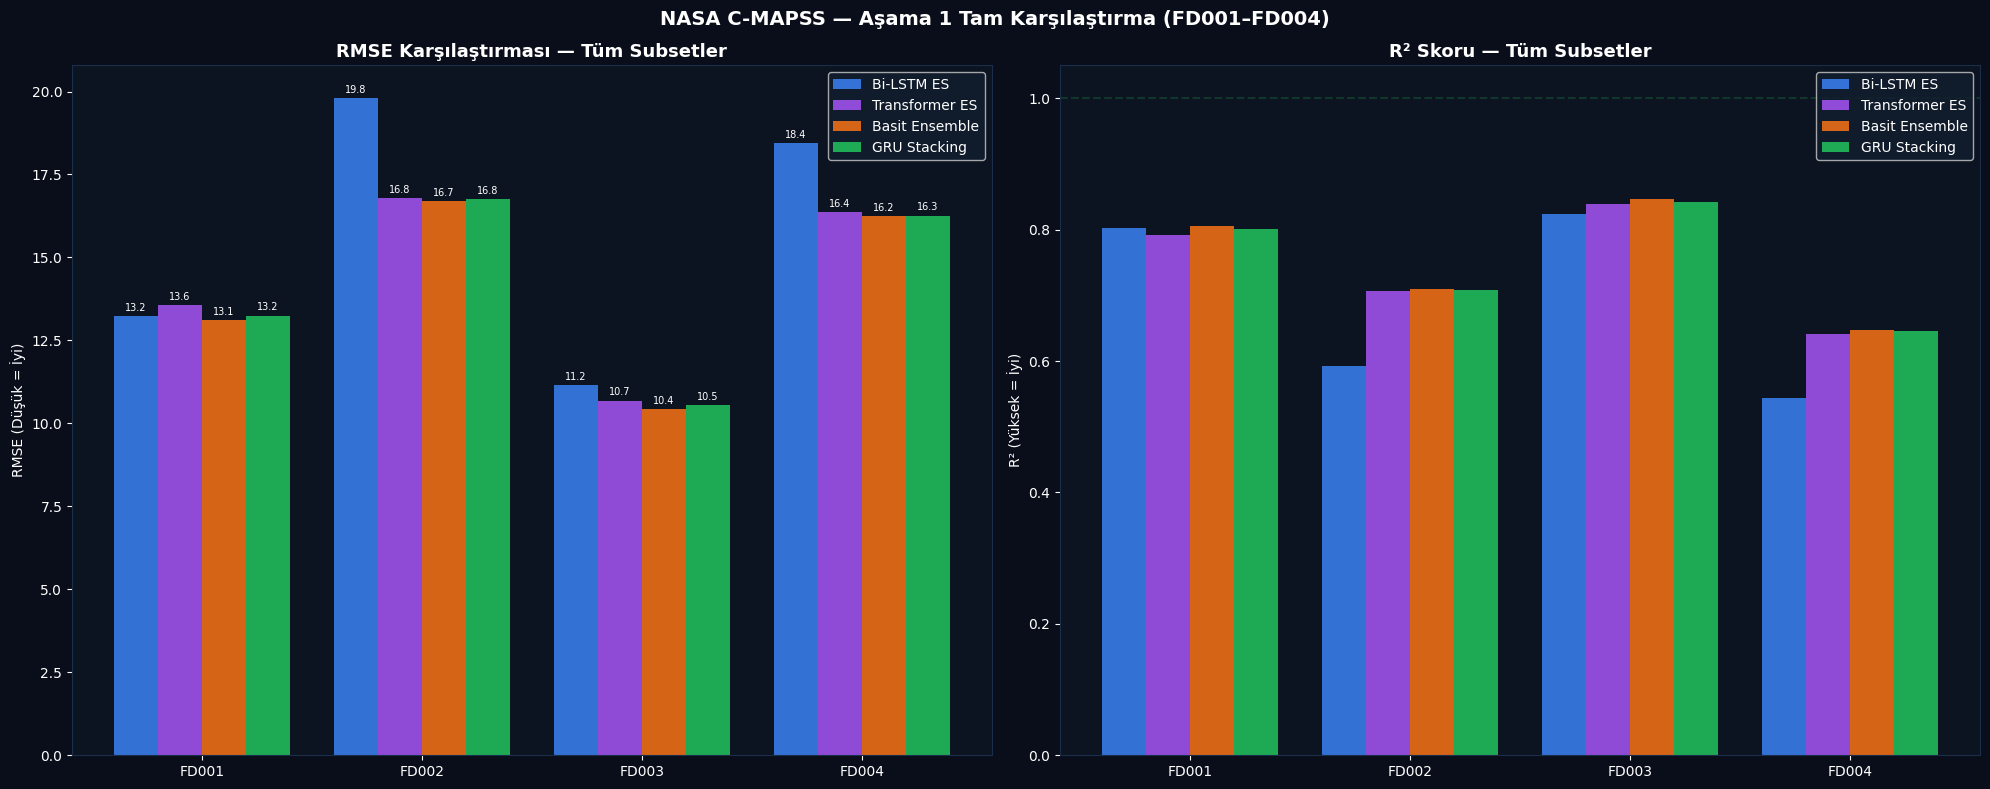

✓ Ana karşılaştırma grafiği → /content/drive/MyDrive/cmapss_asama1/asama1_tum_subsetler.png


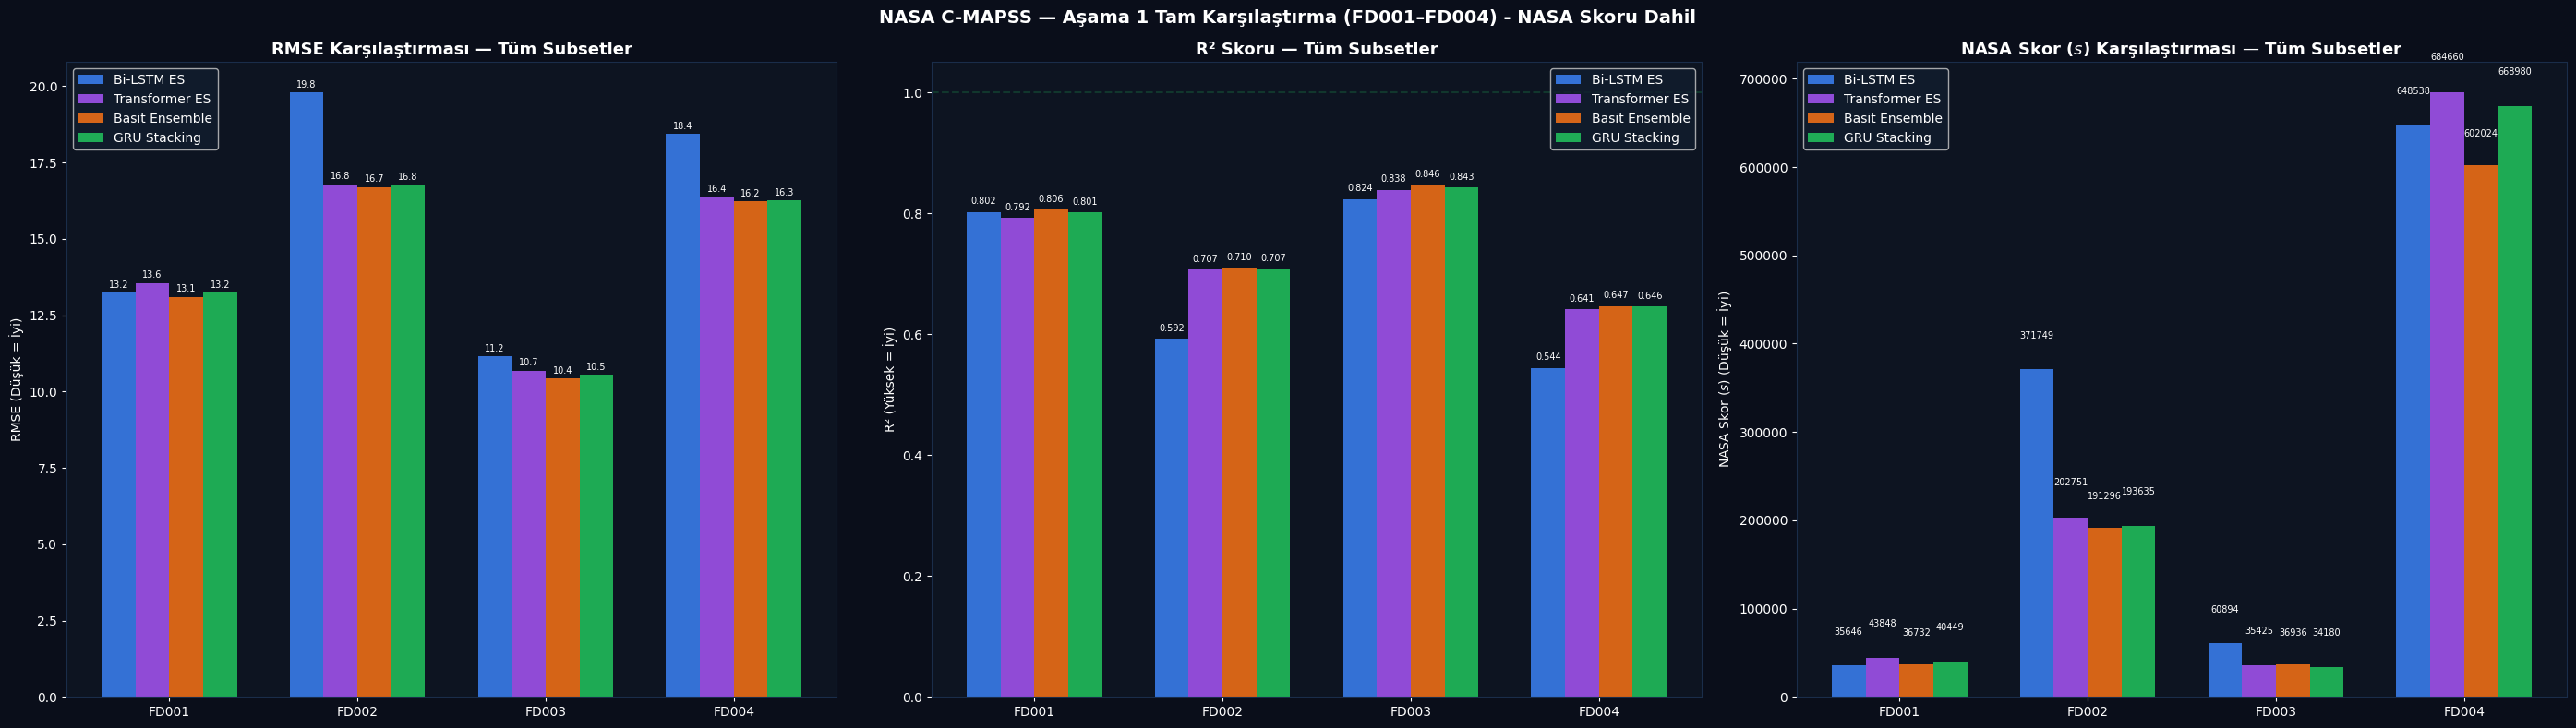


✓ Ana karşılaştırma grafiği (NASA Skor dahil) → /content/drive/MyDrive/cmapss_asama1/asama1_tum_subsetler_nasa_skor.png
✓ Tam sonuçlar → /content/drive/MyDrive/cmapss_asama1/asama1_tum_sonuclar.csv

  AŞAMA 1 TAMAMLANDI — TÜM SUBSETLER
  ─────────────────────────────────────────
  Sıradaki: Aşama 2 — Multi-Scale CNN + SHAP


In [14]:
# ╔══════════════════════════════════════════════════╗
# ║  ANA ÇALIŞTIRMA                                 ║
# ╚══════════════════════════════════════════════════╝

all_results = {}

# FD001 — checkpoint'ler hazır, eğitim atlanır
for subset in ['FD001', 'FD002', 'FD003', 'FD004']:
    all_results[subset] = run_subset(subset)

# ── Tüm Subsetler Karşılaştırma Tablosu ──────────
print(f"\n{'='*72}")
print(f"  AŞAMA 1 — TÜM SUBSETLER ÖZET TABLOSU")
print(f"{'='*72}")

rows = []
for ss in ['FD001','FD002','FD003','FD004']:
    r = all_results[ss]
    for lbl, mk in [('Bi-LSTM ES','bilstm'),('Transformer ES','transf'),
                     ('Basit Ensemble','simple'),('GRU Stacking','meta')]:
        m  = r[mk]
        mk2 = " ★" if abs(m['RMSE']-r['best_rmse'])<0.001 else ""
        ep  = str(m.get('best_ep','—'))
        rows.append({'Subset':ss,'Model':lbl,
                     'RMSE':round(m['RMSE'],4),'R2':round(m['R2'],4),
                     'Score':round(m['Score'],1),'Best_Ep':ep})

df_results = pd.DataFrame(rows)
display(df_results)

# Ana karşılaştırma grafiği
plot_all_subsets(all_results)
plot_all_subsets_with_nasa_score(all_results)

# CSV kaydet
csv_path = os.path.join(BASE_OUT, 'asama1_tum_sonuclar.csv')
pd.DataFrame(rows).to_csv(csv_path, index=False)
print(f"✓ Tam sonuçlar → {csv_path}")

print(f"\n{'='*62}")
print(f"  AŞAMA 1 TAMAMLANDI — TÜM SUBSETLER")
print(f"  ─────────────────────────────────────────")
print(f"  Sıradaki: Aşama 2 — Multi-Scale CNN + SHAP")
print(f"{'='*62}")

In [13]:
# ╔══════════════════════════════════════════════════╗
# ║  4 SUBSET KARŞILAŞTIRMA GRAFİĞİ (NASA Skor ile) ║
# ╚══════════════════════════════════════════════════╝

def plot_all_subsets_with_nasa_score(all_results):
    """
    4 subset x 4 model RMSE, R² ve NASA Skor karşılaştırması.
    """
    subsets = ['FD001','FD002','FD003','FD004']
    models  = ['bilstm','transf','simple','meta']
    lbls    = ['Bi-LSTM ES','Transformer ES','Basit Ensemble','GRU Stacking']
    colors  = ['#3b82f6','#a855f7','#f97316','#22c55e']

    # Adjust figsize for three subplots
    fig, axes = plt.subplots(1, 3, figsize=(28, 8), facecolor='#0a0e1a')
    BG='#0d1421'; TXT='white'
    x = np.arange(len(subsets)); w = 0.18 # Adjusted width for more bars

    def sty(ax, t):
        ax.set_facecolor(BG); ax.set_title(t, color=TXT, fontsize=13, fontweight='bold')
        ax.tick_params(colors=TXT); ax.set_xticks(x); ax.set_xticklabels(subsets, color=TXT)
        for sp in ax.spines.values(): sp.set_edgecolor('#1a2d4a')

    # RMSE grouped bar
    ax = axes[0]; sty(ax, 'RMSE Karşılaştırması — Tüm Subsetler')
    for i, (mk, lbl, col) in enumerate(zip(models, lbls, colors)):
        vals = [all_results[s][mk]['RMSE'] for s in subsets]
        bars = ax.bar(x + (i-1.5)*w, vals, w, label=lbl, color=col, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+w/2, v+0.1, f'{v:.1f}',
                    ha='center', va='bottom', color=TXT, fontsize=7)
    ax.set_ylabel('RMSE (Düşük = İyi)', color=TXT)
    ax.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=10)

    # R² grouped bar
    ax = axes[1]; sty(ax, 'R² Skoru — Tüm Subsetler')
    for i, (mk, lbl, col) in enumerate(zip(models, lbls, colors)):
        vals = [all_results[s][mk]['R2'] for s in subsets]
        bars = ax.bar(x + (i-1.5)*w, vals, w, label=lbl, color=col, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+w/2, v+0.01, f'{v:.3f}',
                    ha='center', va='bottom', color=TXT, fontsize=7)
    ax.set_ylabel('R² (Yüksek = İyi)', color=TXT)
    ax.set_ylim(0, 1.05)
    ax.axhline(1.0, color='#22c55e', linestyle='--', alpha=0.2)
    ax.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=10)

    # NASA Score grouped bar
    ax = axes[2]; sty(ax, 'NASA Skor ($s$) Karşılaştırması — Tüm Subsetler')
    for i, (mk, lbl, col) in enumerate(zip(models, lbls, colors)):
        vals = [all_results[s][mk]['Score'] for s in subsets]
        bars = ax.bar(x + (i-1.5)*w, vals, w, label=lbl, color=col, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+w/2, v+0.05*max(vals), f'{v:.0f}', # Adjust vertical offset dynamically
                    ha='center', va='bottom', color=TXT, fontsize=7)
    ax.set_ylabel('NASA Skor ($s$) (Düşük = İyi)', color=TXT)
    ax.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=10)


    fig.suptitle('NASA C-MAPSS — Aşama 1 Tam Karşılaştırma (FD001–FD004) - NASA Skoru Dahil',
                 color=TXT, fontsize=14, fontweight='bold')
    plt.tight_layout()
    out = os.path.join(BASE_OUT, 'asama1_tum_subsetler_nasa_skor.png')
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
    plt.show()
    print(f"\n✓ Ana karşılaştırma grafiği (NASA Skor dahil) → {out}")